**Importing the libraries**

In [1]:
import numpy as np
import tensorflow as tf
import glob 
import os 
from PIL import Image
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from keras.optimizers import Adam
from tensorflow.keras.applications import Xception

2025-02-01 19:10:32.439763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738437032.462564   70159 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738437032.469720   70159 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-01 19:10:32.494399: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [17]:
conv_base= Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(410,410,3)
)

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_gen= ImageDataGenerator(rescale=1./255)

In [30]:
train_generator = data_gen.flow_from_directory(
    "train_data",  
    target_size=(410,410),
    batch_size=64,  
    class_mode='sparse', 
    shuffle=True  
)
val_data = data_gen.flow_from_directory(
    "validation_data",
    target_size=(410,410),
    batch_size=64,  
    class_mode='sparse', 
    shuffle=True  
)
test_data= data_gen.flow_from_directory(
    "test_data",
    target_size=(410,410),
    batch_size=64,  
    class_mode='sparse', 
    shuffle=True  
)

Found 100000 images belonging to 2 classes.
Found 30000 images belonging to 2 classes.
Found 70000 images belonging to 2 classes.


In [28]:

model = Sequential()

model.add(conv_base)

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))

conv_base.trainable=True
for layer in conv_base.layers[:100]:
    layer.trainable= False

model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 13, 13, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 346112)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    44,302,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,172,330 (248.61 MB)

 Trainable params: 53,789,194 (205.19 MB)

 Non-trainable params: 11,383,136 (43.42 MB)

In [31]:
history=model.fit(train_generator,epochs=10,validation_data=val_data,verbose=1)

Epoch 1/10


I0000 00:00:1738437652.335785   70363 service.cc:148] XLA service 0x5897561a7880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738437652.335838   70363 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738437652.335844   70363 service.cc:156]   StreamExecutor device (1): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738437652.335847   70363 service.cc:156]   StreamExecutor device (2): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738437652.335851   70363 service.cc:156]   StreamExecutor device (3): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738437652.335855   70363 service.cc:156]   StreamExecutor device (4): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
I0000 00:00:1738437652.335858   70363 service.cc:156]   StreamExecutor device (5): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
2025-02-01 19:20:52.727753:

 837/1563 ━━━━━━━━━━━━━━━━━━━━ 7:30 620ms/step - accuracy: 0.8359 - loss: 0.3515 

2025-02-01 19:30:05.197276: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-02-01 19:30:06.043489: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 10.09GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-02-01 19:30:06.555490: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.59GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-02-01 19:30:07.166115: W external/local_xla/xla/t

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1238s 768ms/step - accuracy: 0.8904 - loss: 0.2357 - val_accuracy: 0.9966 - val_loss: 0.0106
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1167s 747ms/step - accuracy: 0.9983 - loss: 0.0044 - val_accuracy: 0.9941 - val_loss: 0.0173
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1167s 746ms/step - accuracy: 0.9992 - loss: 0.0025 - val_accuracy: 0.9993 - val_loss: 0.0025
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1166s 746ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9994 - val_loss: 0.0020
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1166s 746ms/step - accuracy: 0.9990 - loss: 0.0034 - val_accuracy: 0.9997 - val_loss: 0.0016
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1166s 746ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9976 - val_loss: 0.0100
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1166s 746ms/step - accuracy: 0.9998 - loss: 8.1193e-04 - val_accuracy: 0.9996 - val_loss: 0.0019
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1166s 746ms/step - a

In [32]:
loss, accuracy = model.evaluate(test_data, steps=test_data.samples // test_data.batch_size, verbose=1)

print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")


1093/1093 ━━━━━━━━━━━━━━━━━━━━ 808s 739ms/step - accuracy: 0.9997 - loss: 0.0012     
Loss: 0.0011442303657531738
Accuracy: 0.9996997714042664


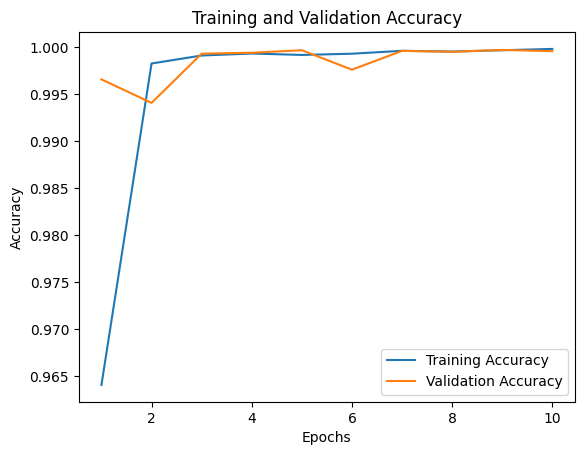

In [33]:
train_accuracy = history.history['accuracy']  
val_accuracy = history.history['val_accuracy']  
epochs = range(1, len(train_accuracy) + 1)  
import matplotlib.pyplot as plt

plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.savefig("Adam_Pretrained_Accuracy.png")
plt.show()



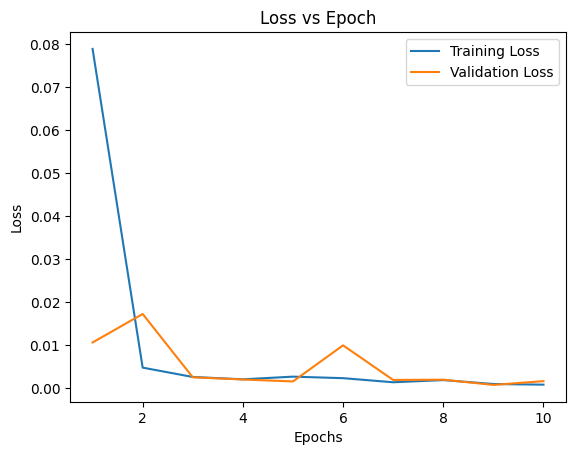

In [34]:
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']  

plt.plot(epochs, loss_values, label='Training Loss')  
plt.plot(epochs, val_loss_values, label='Validation Loss') 
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.savefig("Adam_Pretrained_loss.png")
plt.show()

In [35]:
model.save('QR_Code_Classifier_Pretrained_Adam.h5')
model.save_weights('pretrained_adam_model.weights.h5')

In [ ]:
from tensorflow.keras.preprocessing import image


img_path = 'QR codes/malicious/malicious/malicious_316262.png'

# Preprocess the image
img = image.load_img(img_path, target_size=(224, 224)) 
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array /= 255.0 

prediction = model.predict(img_array)

print(f"Predicted Class: {np.argmax(prediction)}")

In [ ]:

img_path = 'QR codes/benign/benign/benign_15.png'

# Preprocess the image
img = image.load_img(img_path, target_size=(224, 224)) 
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array /= 255.0 

prediction = model.predict(img_array)

print(f"Predicted Class: {np.argmax(prediction)}")